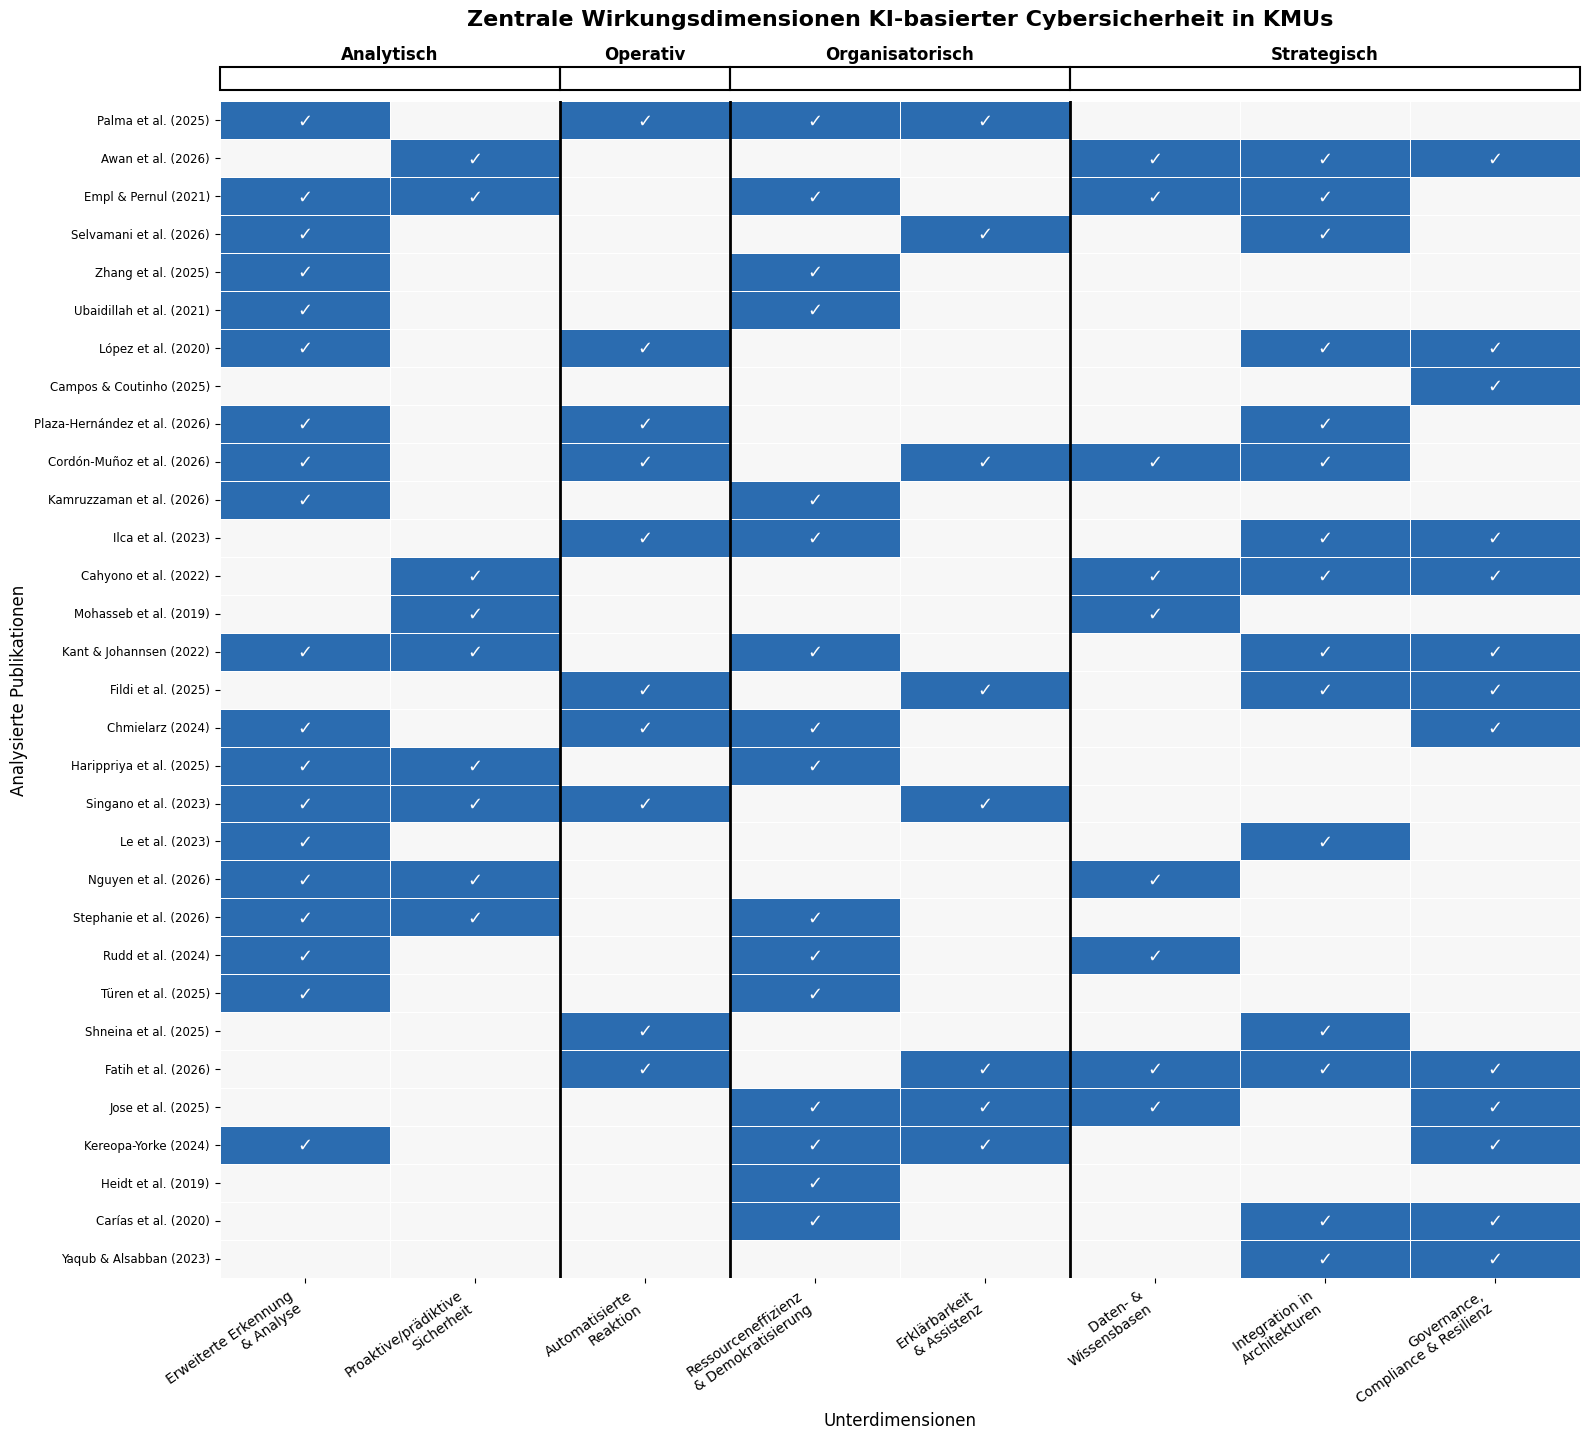

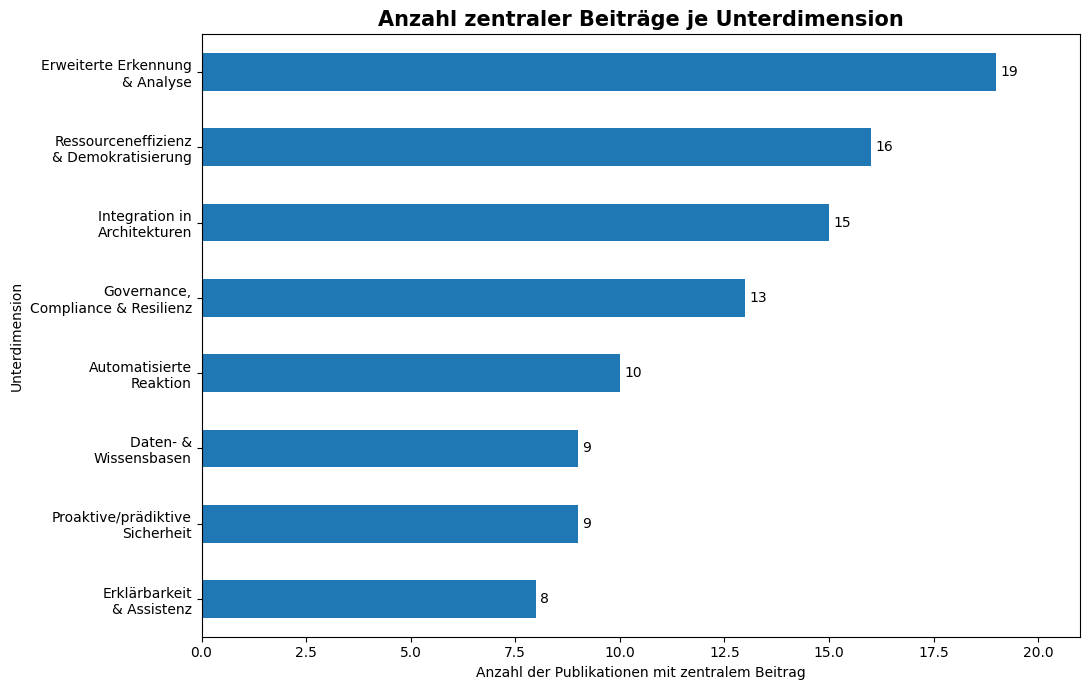

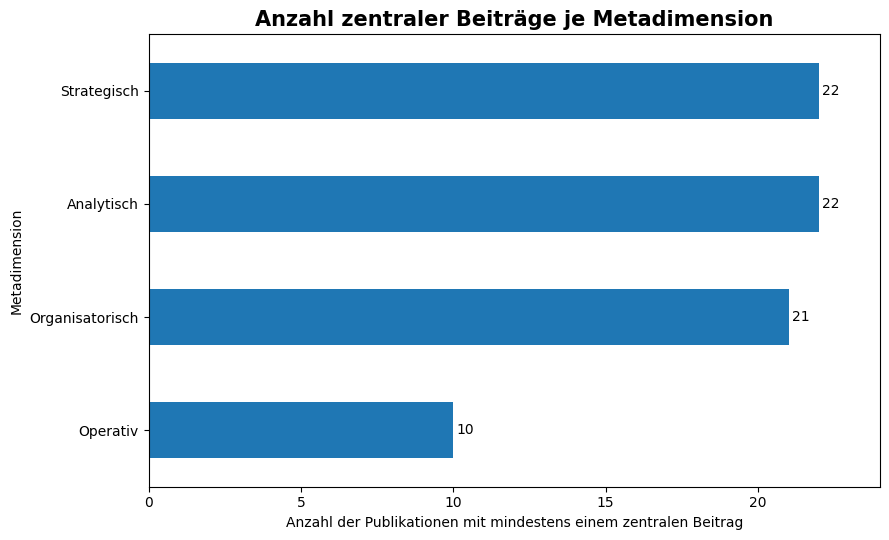

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap

# ------------------------------------------------------------
# Binäre Konzeptmatrix (31 Publikationen)
# 1 = zentrales Konzept
# 0 = kein zentrales Konzept
# ------------------------------------------------------------

data = [
    ["Palma et al. (2025)",              1, 1, 0, 1, 1, 0, 0, 0],
    ["Awan et al. (2026)",               0, 0, 1, 0, 0, 1, 1, 1],
    ["Empl & Pernul (2021)",             1, 1, 1, 0, 0, 1, 1, 0],
    ["Selvamani et al. (2026)",          0, 1, 0, 0, 1, 0, 1, 0],
    ["Zhang et al. (2025)",              1, 1, 0, 0, 0, 0, 0, 0],
    ["Ubaidillah et al. (2021)",         1, 1, 0, 0, 0, 0, 0, 0],
    ["López et al. (2020)",              0, 1, 0, 1, 0, 0, 1, 1],
    ["Campos & Coutinho (2025)",         0, 0, 0, 0, 0, 0, 0, 1],
    ["Plaza-Hernández et al. (2026)",    0, 1, 0, 1, 0, 0, 1, 0],
    ["Cordón-Muñoz et al. (2026)",       0, 1, 0, 1, 1, 1, 1, 0],
    ["Kamruzzaman et al. (2026)",        1, 1, 0, 0, 0, 0, 0, 0],
    ["Ilca et al. (2023)",               1, 0, 0, 1, 0, 0, 1, 1],
    ["Cahyono et al. (2022)",            0, 0, 1, 0, 0, 1, 1, 1],
    ["Mohasseb et al. (2019)",           0, 0, 1, 0, 0, 1, 0, 0],
    ["Kant & Johannsen (2022)",          1, 1, 1, 0, 0, 0, 1, 1],
    ["Fildi et al. (2025)",              0, 0, 0, 1, 1, 0, 1, 1],
    ["Chmielarz (2024)",                 1, 1, 0, 1, 0, 0, 0, 1],
    ["Harippriya et al. (2025)",         1, 1, 1, 0, 0, 0, 0, 0],
    ["Singano et al. (2023)",            0, 1, 1, 1, 1, 0, 0, 0],
    ["Le et al. (2023)",                 0, 1, 0, 0, 0, 0, 1, 0],
    ["Nguyen et al. (2026)",             0, 1, 1, 0, 0, 1, 0, 0],
    ["Stephanie et al. (2026)",          1, 1, 1, 0, 0, 0, 0, 0],
    ["Rudd et al. (2024)",               1, 1, 0, 0, 0, 1, 0, 0],
    ["Türen et al. (2025)",              1, 1, 0, 0, 0, 0, 0, 0],
    ["Shneina et al. (2025)",            0, 0, 0, 1, 0, 0, 1, 0],
    ["Fatih et al. (2026)",              0, 0, 0, 1, 1, 1, 1, 1],
    ["Jose et al. (2025)",               1, 0, 0, 0, 1, 1, 0, 1],

    # Snowballing-Publikationen
    ["Kereopa-Yorke (2024)",             1, 1, 0, 0, 1, 0, 0, 1],
    ["Heidt et al. (2019)",              1, 0, 0, 0, 0, 0, 0, 0],
    ["Carías et al. (2020)",             1, 0, 0, 0, 0, 0, 1, 1],
    ["Yaqub & Alsabban (2023)",          0, 0, 0, 0, 0, 0, 1, 1],
]

columns = [
    "Paper",
    "Ressourceneffizienz\n& Demokratisierung",
    "Erweiterte Erkennung\n& Analyse",
    "Proaktive/prädiktive\nSicherheit",
    "Automatisierte\nReaktion",
    "Erklärbarkeit\n& Assistenz",
    "Daten- &\nWissensbasen",
    "Integration in\nArchitekturen",
    "Governance,\nCompliance & Resilienz"
]

df = pd.DataFrame(data, columns=columns).set_index("Paper")


# ------------------------------------------------------------
# Spalten nach den vier Metadimensionen sortieren
# ------------------------------------------------------------

ordered_columns = [
    # Analytisch
    "Erweiterte Erkennung\n& Analyse",
    "Proaktive/prädiktive\nSicherheit",

    # Operativ
    "Automatisierte\nReaktion",

    # Organisatorisch
    "Ressourceneffizienz\n& Demokratisierung",
    "Erklärbarkeit\n& Assistenz",

    # Strategisch
    "Daten- &\nWissensbasen",
    "Integration in\nArchitekturen",
    "Governance,\nCompliance & Resilienz"
]

df = df[ordered_columns]

annot = df.replace({1: "✓", 0: ""})

plt.figure(figsize=(16, 14.5))

cmap = ListedColormap(["#f7f7f7", "#2b6cb0"])

ax = sns.heatmap(
    df,
    cmap=cmap,
    linewidths=0.5,
    linecolor="white",
    cbar=False,
    annot=annot,
    fmt="",
    annot_kws={"fontsize": 13, "fontweight": "bold"}
)

ax.set_title(
    "Zentrale Wirkungsdimensionen KI-basierter Cybersicherheit in KMUs",
    fontsize=16,
    fontweight="bold",
    pad=55
)

ax.set_xlabel("Unterdimensionen", fontsize=12)
ax.set_ylabel("Analysierte Publikationen", fontsize=12)

plt.xticks(rotation=35, ha="right", fontsize=10)
plt.yticks(fontsize=8.5)


# ------------------------------------------------------------
# Metadimensionen
# ------------------------------------------------------------

groups = [
    (0, 2, "Analytisch"),
    (2, 1, "Operativ"),
    (3, 2, "Organisatorisch"),
    (5, 3, "Strategisch"),
]

for x in [2, 3, 5]:
    ax.axvline(x=x, color="black", linewidth=2)

for start, width, label in groups:
    center = start + width / 2

    ax.text(
        center,
        -1.25,
        label,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    rect = Rectangle(
        (start, -0.9),
        width,
        0.6,
        fill=False,
        edgecolor="black",
        linewidth=1.5,
        clip_on=False
    )
    ax.add_patch(rect)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Häufigkeit zentraler Konzepte je Unterdimension
# ------------------------------------------------------------

concept_counts = df.sum().sort_values(ascending=True)

plt.figure(figsize=(11, 7))

ax = concept_counts.plot(kind="barh")

ax.set_title(
    "Anzahl zentraler Beiträge je Unterdimension",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Anzahl der Publikationen mit zentralem Beitrag")
ax.set_ylabel("Unterdimension")

for i, value in enumerate(concept_counts.values):
    ax.text(
        value + 0.1,
        i,
        int(value),
        va="center",
        fontsize=10
    )

ax.set_xlim(0, max(concept_counts.values) + 2)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Aggregation nach den vier Metadimensionen
# ------------------------------------------------------------

meta_df = pd.DataFrame(index=df.index)

meta_df["Analytisch"] = df[
    [
        "Erweiterte Erkennung\n& Analyse",
        "Proaktive/prädiktive\nSicherheit"
    ]
].max(axis=1)

meta_df["Operativ"] = df[
    [
        "Automatisierte\nReaktion"
    ]
].max(axis=1)

meta_df["Organisatorisch"] = df[
    [
        "Ressourceneffizienz\n& Demokratisierung",
        "Erklärbarkeit\n& Assistenz"
    ]
].max(axis=1)

meta_df["Strategisch"] = df[
    [
        "Daten- &\nWissensbasen",
        "Integration in\nArchitekturen",
        "Governance,\nCompliance & Resilienz"
    ]
].max(axis=1)

meta_counts = meta_df.sum().sort_values(ascending=True)

plt.figure(figsize=(9, 5.5))

ax = meta_counts.plot(kind="barh")

ax.set_title(
    "Anzahl zentraler Beiträge je Metadimension",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Anzahl der Publikationen mit mindestens einem zentralen Beitrag")
ax.set_ylabel("Metadimension")

for i, value in enumerate(meta_counts.values):
    ax.text(
        value + 0.1,
        i,
        int(value),
        va="center",
        fontsize=10
    )

ax.set_xlim(0, max(meta_counts.values) + 2)

plt.tight_layout()
plt.show()